# Model Training and Eval
Trains two models on the return-risk task and evaluates both HONESTLY on the held-out (chronological) test set:
1. Logistic Regression - fully interpretable, coefficients read directly as feature contributions.
2. XGBoost             - captures feature interactions, typically stronger on tabular fraud-style data.

Report both but plans DEPLOYING XGBoost

Also implemented the piece the track explicitly asks for: a COST-SENSITIVE THRESHOLD, not just a default 0.5 cutoff. A fraud
classifier's job isn't "get the highest accuracy" -- it's "minimize the merchant's total dollar loss," and false positives and false negatives have very different, documented costs here:
- False Positive cost  = FP_REVIEW_COST (flat), A genuine return gets flagged for manual review / friction.  
Assumption: this costs the merchant a flat review/ops cost plus customer-goodwill risk. We use Rs. 150 as a placeholder -- this number should be replaced with a merchant's real support-ticket cost + estimated churn risk in a production setting.

- False Negative cost  = the order's value (order_value), A genuinely abusive return slips through undetected.  
Assumption: the merchant's loss is proportional to the value of the item being fraudulently returned (not a flat number), since the actual financial exposure scales with order size. This is more realistic than a single flat FN cost.

We sweep decision thresholds and report the TOTAL EXPECTED COST at each one, picking the threshold that minimizes it -- then compare that to the naive default of 0.5, to show explicitly how much a cost-aware threshold saves versus an accuracy-only mindset.

All numbers here are ASSUMPTIONS, clearly labeled. Swap in real costs if available; the machinery (sweep + argmin) doesn't change.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    confusion_matrix, classification_report, average_precision_score,
)
from xgboost import XGBClassifier
import shap

C:\Users\arula\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
FEATURE_LIST_PATH = "../model/feature_columns.json"
PLOTS_DIR = "plots"

FP_REVIEW_COST = 150.0

with open(FEATURE_LIST_PATH) as f:
    feat_meta = json.load(f)
FEATURE_COLS = feat_meta["encoded_feature_columns"]
TARGET = feat_meta["target"]


def load_data():
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
    X_train, y_train = train[FEATURE_COLS], train[TARGET]
    X_test, y_test = test[FEATURE_COLS], test[TARGET]
    return train, test, X_train, y_train, X_test, y_test

## Train both models

In [3]:
def train_models(X_train, y_train):
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    logreg.fit(X_train, y_train)

    # class imbalance ratio for XGBoost's scale_pos_weight
    pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, eval_metric="aucpr",
        random_state=42,
    )
    xgb.fit(X_train, y_train)

    return logreg, xgb

## Evaluation: PR curve, ROC, average precision

In [4]:
def evaluate_model(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    precision, recall, pr_thresholds = precision_recall_curve(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_test, proba)

    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {roc_auc:.3f} | Average Precision (PR-AUC): {ap:.3f}")
    preds_05 = (proba >= 0.5).astype(int)
    print("Classification report @ threshold 0.5:")
    print(classification_report(y_test, preds_05, digits=3))

    return {
        "proba": proba, "precision": precision, "recall": recall,
        "pr_thresholds": pr_thresholds, "fpr": fpr, "tpr": tpr,
        "roc_auc": roc_auc, "avg_precision": ap,
    }


def plot_pr_and_roc(results):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, r in results.items():
        axes[0].plot(r["recall"], r["precision"], label=f"{name} (AP={r['avg_precision']:.3f})")
        axes[1].plot(r["fpr"], r["tpr"], label=f"{name} (AUC={r['roc_auc']:.3f})")

    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision-Recall Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Cost-sensitive threshold sweep (the key "false-positive cost" deliverable)
Sweeps thresholds and reports total expected cost at each one.

**IMPORTANT FINDING** (kept in, not smoothed over): minimizing the flat-FP / value-weighted-FN cost function with NO other constraint pushes the threshold down to ~0.04, which flags roughly 80% of all returns for review. That is mathematically "cheapest" under this cost function, but operationally absurd -- no fraud-ops team can manually review 80% of returns, and a flat Rs.150 review cost does not capture the real cost of treating most genuine customers as suspects (trust erosion, team overload, brand damage aren't linear in flag count).

So reported TWO thresholds:
- "unconstrained_optimal": minimizes total_cost with no other limits.
- "capacity_constrained_optimal": minimizes total_cost subject to flag_rate <= max_flag_rate (default 20% of all returns), a stand-in for a fraud-ops team's real review capacity. This is the one we actually deploy.

In [5]:
def cost_sweep(proba, y_test, order_values, thresholds=None, max_flag_rate=0.20):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    n_total = len(y_test)
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        fp_mask = (preds == 1) & (y_test.values == 0)
        fn_mask = (preds == 0) & (y_test.values == 1)
        tp_mask = (preds == 1) & (y_test.values == 1)

        fp_count = fp_mask.sum()
        fn_count = fn_mask.sum()
        tp_count = tp_mask.sum()
        fp_cost = fp_count * FP_REVIEW_COST
        fn_cost = order_values.values[fn_mask].sum()  # value-weighted, not flat
        total_cost = fp_cost + fn_cost
        flag_rate = (fp_count + tp_count) / n_total

        rows.append({
            "threshold": t, "fp_count": int(fp_count), "fn_count": int(fn_count),
            "tp_count": int(tp_count), "fp_cost": fp_cost, "fn_cost": fn_cost,
            "total_cost": total_cost, "flag_rate": flag_rate,
        })

    cost_df = pd.DataFrame(rows)
    unconstrained_best = cost_df.loc[cost_df["total_cost"].idxmin()]

    feasible = cost_df[cost_df["flag_rate"] <= max_flag_rate]
    constrained_best = feasible.loc[feasible["total_cost"].idxmin()] if len(feasible) else unconstrained_best

    return cost_df, unconstrained_best, constrained_best


def plot_cost_curve(cost_df, unconstrained_best, constrained_best):
    fig, ax1 = plt.subplots(figsize=(9, 5.5))
    ax1.plot(cost_df["threshold"], cost_df["total_cost"], color="tab:blue", label="Total expected cost")
    ax1.axvline(unconstrained_best["threshold"], color="orange", linestyle="--",
                label=f"Unconstrained optimum = {unconstrained_best['threshold']:.2f} "
                      f"(flags {unconstrained_best['flag_rate']:.0%} of returns)")
    ax1.axvline(constrained_best["threshold"], color="green", linestyle="--",
                label=f"Capacity-constrained optimum = {constrained_best['threshold']:.2f} "
                      f"(flags {constrained_best['flag_rate']:.0%} of returns) -- DEPLOYED")
    ax1.axvline(0.5, color="red", linestyle=":", label="Naive default = 0.50")
    ax1.set_xlabel("Decision threshold")
    ax1.set_ylabel("Total expected cost (Rs.)", color="tab:blue")
    ax1.set_title("Cost-sensitive threshold selection\n(FP = flat review cost, FN = value-weighted loss, "
                   "constrained by review capacity)")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(cost_df["threshold"], cost_df["flag_rate"], color="gray", alpha=0.5, label="Flag rate")
    ax2.set_ylabel("Flag rate (% of returns sent to review)", color="gray")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_confusion(y_test, proba, threshold, title_suffix=""):
    preds = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.xticks([0, 1], ["Pred: Genuine", "Pred: Abusive"])
    plt.yticks([0, 1], ["True: Genuine", "True: Abusive"])
    plt.title(f"Confusion Matrix @ threshold={threshold:.2f}{title_suffix}", fontsize=11)
    plt.tight_layout()
    plt.show()


# SHAP explainability for the deployed model

In [6]:
def plot_shap_summary(xgb_model, X_test, sample_n=500):
    sample = X_test.sample(min(sample_n, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer(sample)
    shap.summary_plot(shap_values, sample, show=False)
    plt.tight_layout()
    plt.show()


=== Logistic Regression ===
ROC-AUC: 0.898 | Average Precision (PR-AUC): 0.723
Classification report @ threshold 0.5:
              precision    recall  f1-score   support

           0      0.959     0.951     0.955      2246
           1      0.672     0.712     0.691       316

    accuracy                          0.922      2562
   macro avg      0.815     0.832     0.823      2562
weighted avg      0.924     0.922     0.923      2562


=== XGBoost ===
ROC-AUC: 0.904 | Average Precision (PR-AUC): 0.733
Classification report @ threshold 0.5:
              precision    recall  f1-score   support

           0      0.963     0.949     0.956      2246
           1      0.672     0.741     0.705       316

    accuracy                          0.923      2562
   macro avg      0.818     0.845     0.830      2562
weighted avg      0.927     0.923     0.925      2562



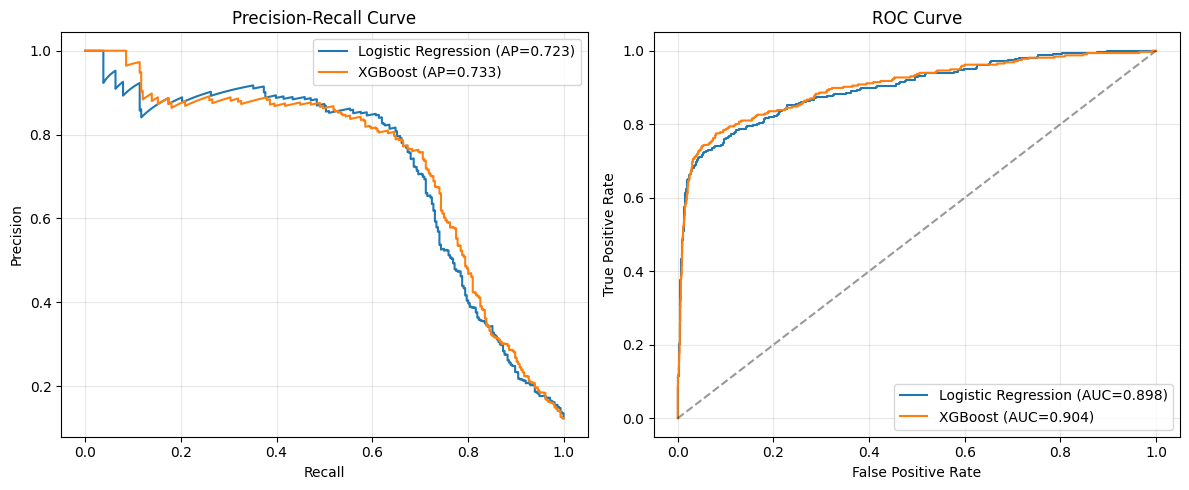

In [7]:
train, test, X_train, y_train, X_test, y_test = load_data()

logreg, xgb = train_models(X_train, y_train)

results = {
    "Logistic Regression": evaluate_model("Logistic Regression", logreg, X_test, y_test),
    "XGBoost": evaluate_model("XGBoost", xgb, X_test, y_test),
}
plot_pr_and_roc(results)

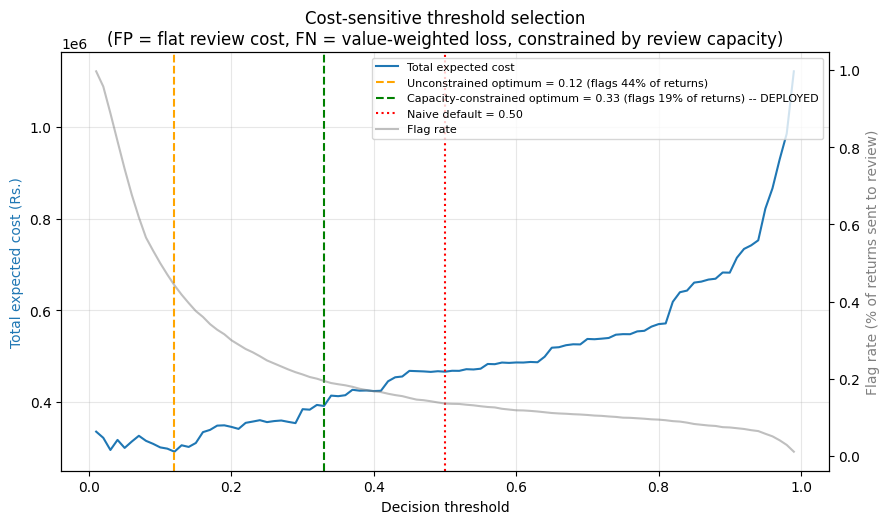

In [8]:
# Cost-sensitive threshold using the DEPLOYED model (XGBoost)
deployed_proba = results["XGBoost"]["proba"]
order_values = test["order_value"]
cost_df, unconstrained_best, constrained_best = cost_sweep(
    deployed_proba, y_test, order_values, max_flag_rate=0.20
)
plot_cost_curve(cost_df, unconstrained_best, constrained_best)


=== Cost-sensitive threshold (deployed model: XGBoost) ===
Unconstrained optimum: threshold=0.12, cost=Rs.291,916, flag_rate=44.2%  <- mathematically cheapest, operationally unrealistic (flags most returns)
Capacity-constrained optimum (<=20% flag rate) -- DEPLOYED: threshold=0.33, cost=Rs.391,674, flag_rate=19.4%
Naive default (0.5): cost=Rs.466,447
Savings vs naive default: Rs. 74,773


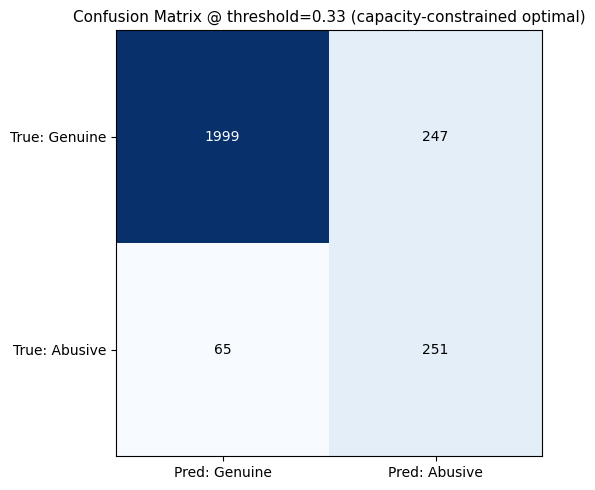

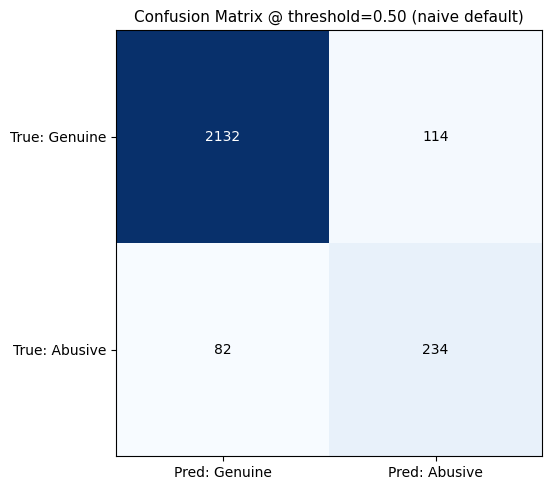

In [9]:
optimal_threshold = float(constrained_best["threshold"])  # what we actually deploy
naive_cost = cost_df.loc[cost_df["threshold"].sub(0.5).abs().idxmin(), "total_cost"]

print(f"\n=== Cost-sensitive threshold (deployed model: XGBoost) ===")
print(f"Unconstrained optimum: threshold={unconstrained_best['threshold']:.2f}, "
      f"cost=Rs.{unconstrained_best['total_cost']:,.0f}, "
      f"flag_rate={unconstrained_best['flag_rate']:.1%}  <- mathematically cheapest, "
      f"operationally unrealistic (flags most returns)")
print(f"Capacity-constrained optimum (<=20% flag rate) -- DEPLOYED: "
      f"threshold={optimal_threshold:.2f}, cost=Rs.{constrained_best['total_cost']:,.0f}, "
      f"flag_rate={constrained_best['flag_rate']:.1%}")
print(f"Naive default (0.5): cost=Rs.{naive_cost:,.0f}")
print(f"Savings vs naive default: Rs. {naive_cost - constrained_best['total_cost']:,.0f}")
plot_confusion(y_test, deployed_proba, optimal_threshold," (capacity-constrained optimal)")
plot_confusion(y_test, deployed_proba, 0.5, " (naive default)")

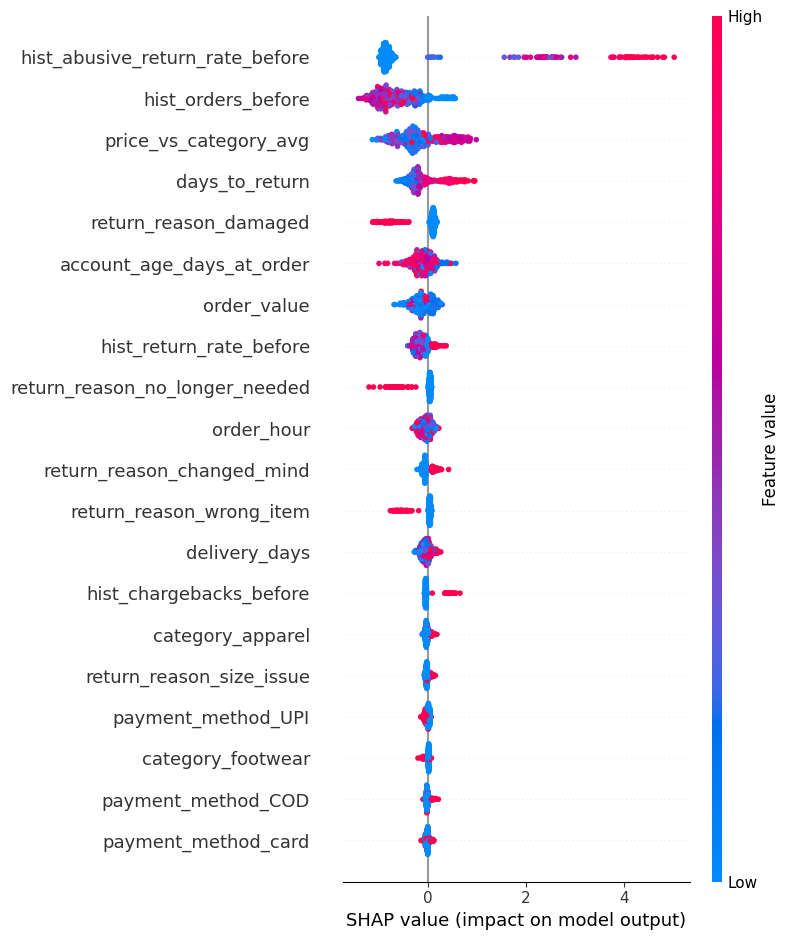

In [10]:
plot_shap_summary(xgb, X_test)